In [57]:
import jax.numpy as jnp
from jax import random
import jax
from flax.training import train_state
import optax
from flax import linen as nn
from tqdm.notebook import tqdm
# Optionally, you can save the losses to a file or plot them
import matplotlib.pyplot as plt
import numpy as np

In [25]:
class CustomNN(nn.Module):
    alpha: float
    epsilon: float
    N: int
    d: int

    def setup(self):
        # Initialize weights with shape (N, input_dim)
        self.w = self.param('w', nn.initializers.lecun_normal(), (self.N, self.d))

    def __call__(self, x):
        # Compute the inner product w_i . x for each i
        inner_product = jnp.dot(self.w, x.T)  # Shape: (N, batch_size)

        # Apply the function phi(h) = h + (epsilon / 2) * h^2
        phi = inner_product + (self.epsilon / 2) * jnp.square(inner_product)

        # Sum over the N dimension and scale by alpha / N
        result = (self.alpha / self.N) * jnp.sum(phi, axis=0)  # Shape: (batch_size,)

        return result

In [26]:
def generate_data(D, num_samples, key):
    x = jax.random.normal(key, (num_samples, D)) / jnp.sqrt(D)
    beta_star = jax.random.normal(key, (D,))
    y = 0.5 * jnp.square(jnp.dot(x, beta_star))
    return x, y

In [27]:
def create_train_state(model, key, x, learning_rate):
    params = model.init(key, x)
    tx = optax.adam(learning_rate)
    return train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

In [ ]:
def train_model(state, train_ds, test_ds, num_epochs, batch_size, alpha):
    train_x, train_y = train_ds
    test_x, test_y = test_ds

    train_steps_per_epoch = len(train_x) // batch_size

    train_losses = []
    test_losses = []

    # Compute initial predictions f(x, theta_0)
    initial_preds_train = state.apply_fn(state.params, train_x)
    initial_preds_test = state.apply_fn(state.params, test_x)

    @jax.jit
    def train_step(state, batch_x, batch_y, initial_preds):
        def loss_fn(params):
            preds = state.apply_fn(params, batch_x)
            modified_preds = alpha * (preds - initial_preds)
            loss = jnp.mean((modified_preds - batch_y) ** 2)
            return loss
        
        loss, grads = jax.value_and_grad(loss_fn)(state.params)
        state = state.apply_gradients(grads=grads)
        return state, loss
    
    for epoch in tqdm(range(num_epochs)):
        epoch_train_loss = 0.0
        for i in range(train_steps_per_epoch):
            batch_idx = jax.random.randint(jax.random.PRNGKey(i), (batch_size,), 0, len(train_x))
            batch_x = train_x[batch_idx]
            batch_y = train_y[batch_idx]
            batch_initial_preds = initial_preds_train[batch_idx]
            state, batch_loss = train_step(state, batch_x, batch_y, batch_initial_preds)

            epoch_train_loss += batch_loss

        # Average train loss over all batches
        epoch_train_loss /= train_steps_per_epoch
        train_losses.append(epoch_train_loss)

        # Evaluate on test set
        test_preds = state.apply_fn(state.params, test_x)
        test_loss = jnp.mean((test_preds - test_y) ** 2)
        test_losses.append(test_loss)

    return state, train_losses, test_losses

In [ ]:
# Define parameters
alpha = 100
epsilon = 100
N = 10
d = 20
batch_size = 1024
num_epochs = 1000
learning_rate = 0.1 / alpha ** 2

# Create random input data
key = jax.random.PRNGKey(0)
num_samples = 512 * 20
x, y = generate_data(d, num_samples, key)

# Split
n_train = int(len(x) * .8)
train_x, test_x, train_y, test_y = x[:n_train], x[n_train:], y[:n_train], y[n_train:]
train_ds = (train_x, train_y)
test_ds = (test_x, test_y)

In [86]:
# Initialize the model and training state
model = CustomNN(alpha=alpha, epsilon=epsilon, N=N, d=d)
state = create_train_state(model, jax.random.PRNGKey(1), train_x, learning_rate)

# Train the model
state, train_losses, test_losses = train_model(state, train_ds, test_ds, num_epochs, batch_size)


  0%|          | 0/1000 [00:00<?, ?it/s]

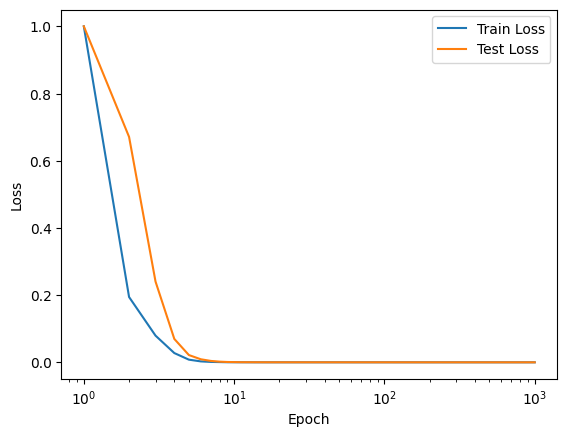

In [87]:
train_losses = np.array(train_losses) / train_losses[0]
test_losses = np.array(test_losses) / test_losses[0]
plt.semilogx(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.semilogx(range(1, num_epochs + 1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()